# Анализ цен на жильё (Housing_Price_Data.csv)

Статистический анализ датасета о ценах на дома: описательные статистики, кодирование категорий и поиск всех корреляций с матрицей корреляций.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Housing_Price_Data.csv")
print("Размер:", df.shape)
df.head()

Размер: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
# Типы столбцов и пропуски
print(df.dtypes, "\n")
print("Всего пропусков:", df.isna().sum().sum())

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object 

Всего пропусков: 0


## 1. Описательная статистика

Числовые признаки: `price`, `area`, `bedrooms`, `bathrooms`, `stories`, `parking`. Остальные — категориальные (yes/no и `furnishingstatus`).

In [3]:
num_cols = ["price", "area", "bedrooms", "bathrooms", "stories", "parking"]
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [4]:
# Категориальные признаки: распределение значений
cat_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
            "airconditioning", "prefarea", "furnishingstatus"]
for c in cat_cols:
    print(c)
    print(df[c].value_counts(), "\n")

mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64 

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64 

basement
basement
no     354
yes    191
Name: count, dtype: int64 

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64 

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64 

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64 

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64 



## 2. Кодирование категорий

Чтобы найти **все** корреляции, переводим категории в числа:
- бинарные yes/no → 1/0;
- `furnishingstatus` — порядковый признак: unfurnished=0, semi-furnished=1, furnished=2.

In [5]:
bin_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
            "airconditioning", "prefarea"]

d = df.copy()
for c in bin_cols:
    d[c] = (d[c] == "yes").astype(int)
d["furnishingstatus"] = d["furnishingstatus"].map(
    {"unfurnished": 0, "semi-furnished": 1, "furnished": 2})

d.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2


## 3. Матрица корреляций

In [6]:
corr = d.corr()
corr.round(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.00,0.54,0.37,0.52,0.42,0.30,0.26,0.19,0.09,0.45,0.38,0.33,0.30
area,0.54,1.00,0.15,0.19,0.08,0.29,0.14,0.05,-0.01,0.22,0.35,0.23,0.17
bedrooms,0.37,0.15,1.00,0.37,0.41,-0.01,0.08,0.10,0.05,0.16,0.14,0.08,0.12
bathrooms,0.52,0.19,0.37,1.00,0.33,0.04,0.13,0.10,0.07,0.19,0.18,0.06,0.14
stories,0.42,0.08,0.41,0.33,1.00,0.12,0.04,-0.17,0.02,0.29,0.05,0.04,0.10
mainroad,0.30,0.29,-0.01,0.04,0.12,1.00,0.09,0.04,-0.01,0.11,0.20,0.20,0.16
guestroom,0.26,0.14,0.08,0.13,0.04,0.09,1.00,0.37,-0.01,0.14,0.04,0.16,0.12
basement,0.19,0.05,0.10,0.10,-0.17,0.04,0.37,1.00,0.00,0.05,0.05,0.23,0.11
hotwaterheating,0.09,-0.01,0.05,0.07,0.02,-0.01,-0.01,0.00,1.00,-0.13,0.07,-0.06,0.03
airconditioning,0.45,0.22,0.16,0.19,0.29,0.11,0.14,0.05,-0.13,1.00,0.16,0.12,0.15


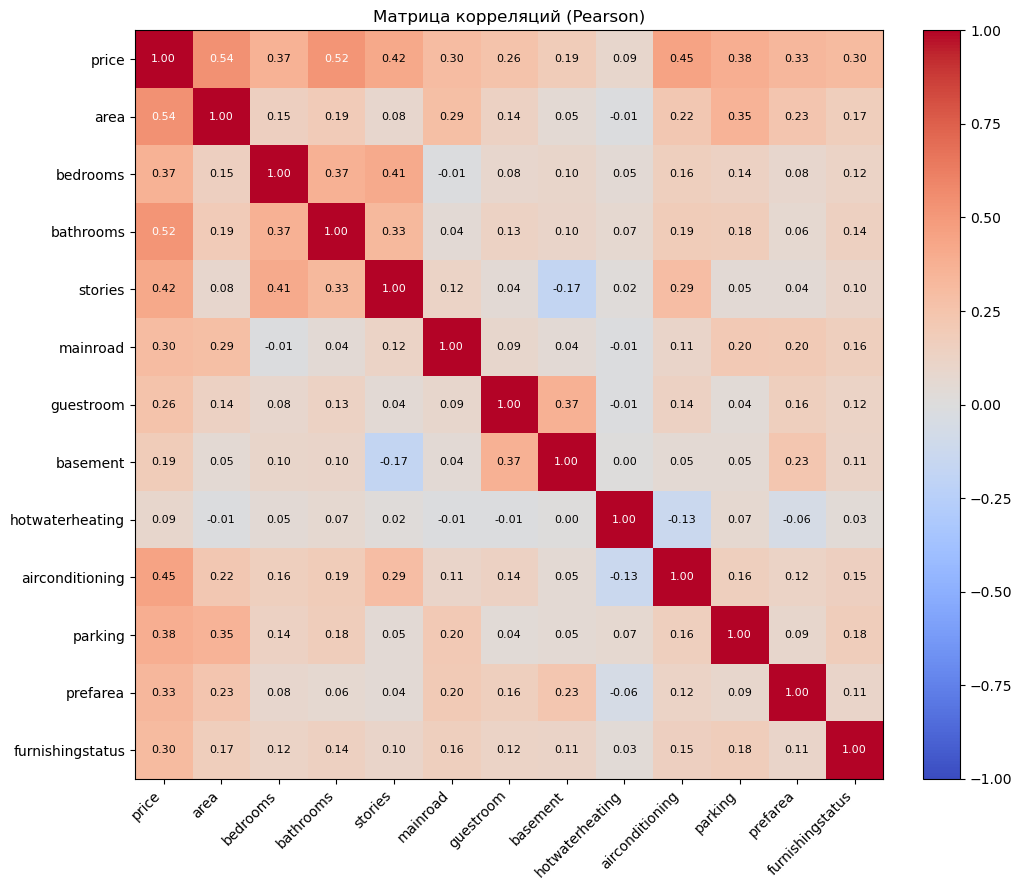

In [7]:
# Тепловая карта матрицы корреляций (чистый matplotlib, seaborn не нужен)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# подписи значений в ячейках
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.5 else "black", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Матрица корреляций (Pearson)")
plt.tight_layout()
plt.show()

## 4. Что сильнее всего влияет на цену

Корреляция каждого признака с `price` + проверка статистической значимости (критерий Пирсона).

In [8]:
from scipy import stats

rows = []
for c in d.columns:
    if c == "price":
        continue
    r, p = stats.pearsonr(d["price"], d[c])
    rows.append({"feature": c, "r_with_price": r, "p_value": p})

price_corr = pd.DataFrame(rows)
price_corr["significant (p<0.05)"] = price_corr["p_value"] < 0.05
price_corr = price_corr.reindex(
    price_corr["r_with_price"].abs().sort_values(ascending=False).index)
price_corr.round(4)

,feature,r_with_price,p_value,significant (p<0.05)
0,area,0.5360,0.0000,True
2,bathrooms,0.5175,0.0000,True
8,airconditioning,0.4530,0.0000,True
3,stories,0.4207,0.0000,True
9,parking,0.3844,0.0000,True
1,bedrooms,0.3665,0.0000,True
10,prefarea,0.3298,0.0000,True
11,furnishingstatus,0.3047,0.0000,True
4,mainroad,0.2969,0.0000,True
5,guestroom,0.2555,0.0000,True


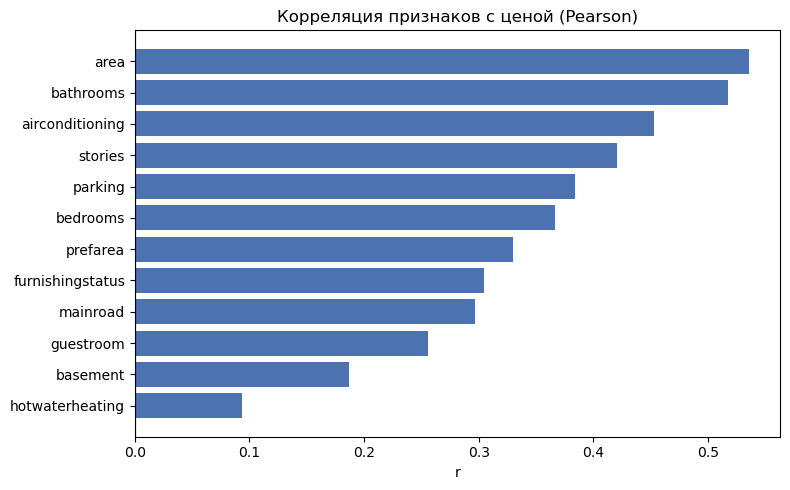

In [9]:
# Корреляция признаков с ценой — горизонтальный barplot
pc = price_corr.sort_values("r_with_price")
colors = ["#d65f5f" if v < 0 else "#4c72b0" for v in pc["r_with_price"]]

plt.figure(figsize=(8, 5))
plt.barh(pc["feature"], pc["r_with_price"], color=colors)
plt.axvline(0, color="k", lw=.8)
plt.title("Корреляция признаков с ценой (Pearson)")
plt.xlabel("r")
plt.tight_layout()
plt.show()

## 5. Самые сильные корреляции во всём датасете (любые пары)

In [10]:
from itertools import combinations

rows = []
for a, b in combinations(d.columns, 2):
    r, p = stats.pearsonr(d[a], d[b])
    rows.append({"pair": f"{a} – {b}", "r": r, "p_value": p})

pairs = pd.DataFrame(rows)
pairs["significant (p<0.05)"] = pairs["p_value"] < 0.05
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index)

print(f"Всего пар: {len(pairs)},  значимых (p<0.05): {int(pairs['significant (p<0.05)'].sum())}\n")
pairs.head(12).round(4)

Всего пар: 78,  значимых (p<0.05): 54



,pair,r,p_value,significant (p<0.05)
0,price – area,0.5360,0.0,True
2,price – bathrooms,0.5175,0.0,True
8,price – airconditioning,0.4530,0.0,True
3,price – stories,0.4207,0.0,True
24,bedrooms – stories,0.4086,0.0,True
9,price – parking,0.3844,0.0,True
23,bedrooms – bathrooms,0.3739,0.0,True
57,guestroom – basement,0.3721,0.0,True
1,price – bedrooms,0.3665,0.0,True
20,area – parking,0.3530,0.0,True


## 6. Где корреляция может быть ложной

Корреляция ложна, когда связь наведена **третьим фактором** (здесь чаще всего — общий «размер/класс дома»), **выбросами** или **множественными сравнениями**. Сравним обычную корреляцию (Pearson) с **частной** (прямая связь при контроле всех остальных признаков) и со **Spearman** (устойчива к выбросам).

In [11]:
# Pearson vs частная (partial) vs Spearman корреляция для всех пар
pear  = d.corr()
spear = d.corr(method="spearman")

# частная корреляция через обратную (прецизионную) матрицу
P = np.linalg.inv(pear.values)
dd = np.sqrt(np.diag(P))
pcorr = pd.DataFrame(-P / np.outer(dd, dd), index=d.columns, columns=d.columns)

rows = []
for a, b in combinations(d.columns, 2):
    pe, pa, sp = pear.loc[a, b], pcorr.loc[a, b], spear.loc[a, b]
    rows.append({
        "pair": f"{a} – {b}",
        "pearson": pe,
        "partial": pa,                         # прямая связь без посредников
        "spearman": sp,
        "drop": abs(pe) - abs(pa),             # >0 => связь во многом через третьи признаки
        "sign_flip": (np.sign(pe) != np.sign(pa)) and abs(pe) > 0.05,
        "outlier_gap": abs(pe - sp),           # большой => тянут выбросы/нелинейность
    })

check = pd.DataFrame(rows)
# подозрение на ложную: связь рушится при контроле либо разворачивает знак
check["подозрит."] = ((check["partial"].abs() < 0.10) & (check["pearson"].abs() > 0.15)) \
                     | check["sign_flip"]
check = check.reindex(check["pearson"].abs().sort_values(ascending=False).index)
check.round(3)


,pair,pearson,partial,spearman,drop,sign_flip,outlier_gap,подозрит.
0,price – area,0.536,0.399,0.603,0.137,False,0.067,False
2,price – bathrooms,0.518,0.383,0.480,0.135,False,0.038,False
8,price – airconditioning,0.453,0.323,0.457,0.130,False,0.004,False
3,price – stories,0.421,0.291,0.363,0.130,False,0.058,False
24,bedrooms – stories,0.409,0.315,0.504,0.094,False,0.096,False
...,...,...,...,...,...,...,...,...
25,bedrooms – mainroad,-0.012,-0.130,-0.004,-0.118,False,0.008,False
52,mainroad – hotwaterheating,-0.012,-0.030,-0.012,-0.018,False,0.000,False
58,guestroom – hotwaterheating,-0.010,-0.017,-0.010,-0.006,False,0.000,False
18,area – hotwaterheating,-0.009,-0.075,-0.014,-0.066,False,0.004,False


Пары с признаками ЛОЖНОЙ корреляции (рушатся или меняют знак при контроле):

                              pair  pearson  partial  spearman
                  price – bedrooms    0.366    0.071     0.390
               bathrooms – stories    0.326    0.071     0.309
                 price – guestroom    0.256    0.097     0.300
                   area – prefarea    0.235    0.050     0.246
            area – airconditioning    0.222   -0.018     0.285
                mainroad – parking    0.204    0.090     0.197
               mainroad – prefarea    0.200    0.093     0.200
                  area – bathrooms    0.194   -0.069     0.214
       bathrooms – airconditioning    0.187   -0.082     0.205
        parking – furnishingstatus    0.178    0.062     0.183
               bathrooms – parking    0.177    0.003     0.174
           area – furnishingstatus    0.171   -0.011     0.170
              guestroom – prefarea    0.161    0.017     0.161
        bedrooms – airconditioning    0.1

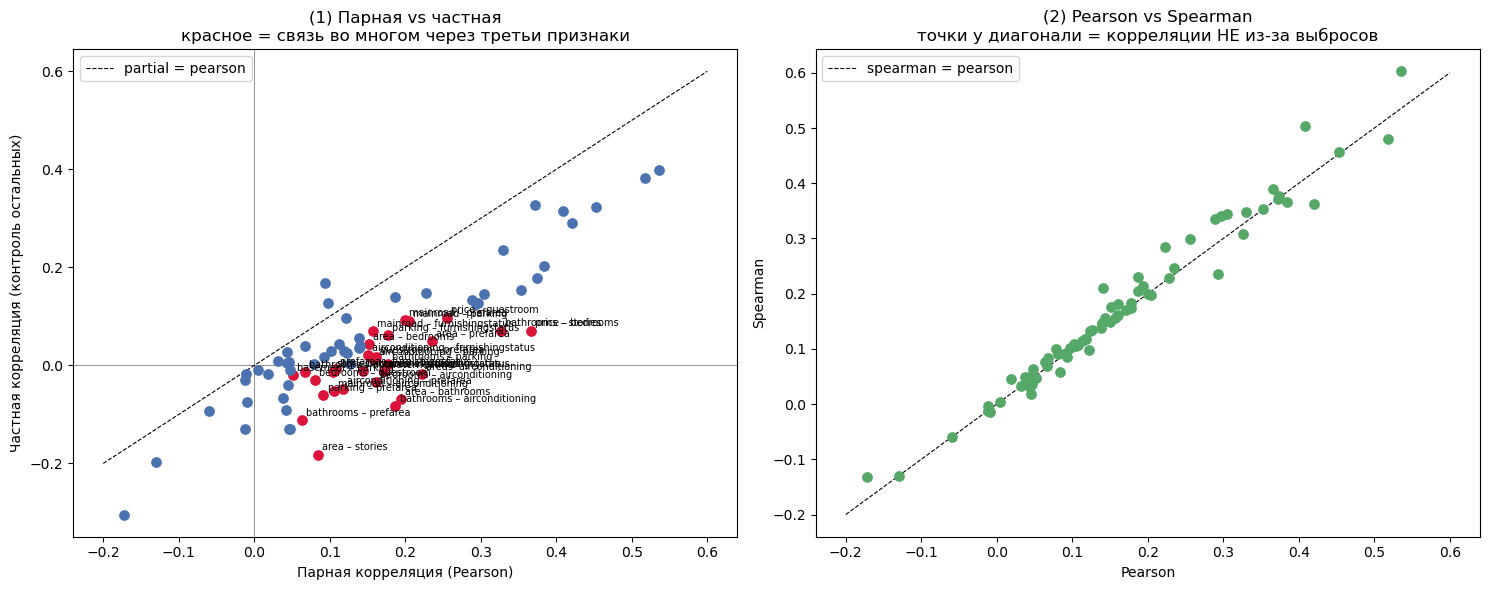

In [12]:
# Подозрительные пары и график "Pearson vs частная"
susp = check[check["подозрит."]].copy()
print("Пары с признаками ЛОЖНОЙ корреляции (рушатся или меняют знак при контроле):\n")
print(susp[["pair", "pearson", "partial", "spearman"]].round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) Pearson vs partial: точки у горизонтали 0 = связь "съедается" контролем
ax = axes[0]
ax.axhline(0, color="gray", lw=.6); ax.axvline(0, color="gray", lw=.6)
ax.plot([-.2, .6], [-.2, .6], "k--", lw=.8, label="partial = pearson")
for _, r in check.iterrows():
    s = r["подозрит."]
    ax.scatter(r["pearson"], r["partial"], c="crimson" if s else "#4c72b0", s=45, zorder=3)
for _, r in susp.iterrows():
    ax.annotate(r["pair"], (r["pearson"], r["partial"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Парная корреляция (Pearson)")
ax.set_ylabel("Частная корреляция (контроль остальных)")
ax.set_title("(1) Парная vs частная\nкрасное = связь во многом через третьи признаки")
ax.legend()

# (2) Pearson vs Spearman: на диагонали = выбросы НЕ искажают
ax = axes[1]
ax.plot([-.2, .6], [-.2, .6], "k--", lw=.8, label="spearman = pearson")
ax.scatter(check["pearson"], check["spearman"], c="#55a868", s=45, zorder=3)
ax.set_xlabel("Pearson"); ax.set_ylabel("Spearman")
ax.set_title("(2) Pearson vs Spearman\nточки у диагонали = корреляции НЕ из-за выбросов")
ax.legend()

plt.tight_layout()
plt.show()


### Где корреляция ложная — выводы

**1. Главный конфаундер — «размер/класс дома».** Многие парные корреляции рушатся при контроле остальных признаков. Самые яркие ложные/обманчивые связи:

| пара | pearson | partial | что произошло |
|---|---|---|---|
| **price – bedrooms** | 0.37 | **0.07** | связь почти исчезает: спальни «дорожают» не сами по себе, а потому что идут вместе с площадью, санузлами, этажами |
| **bathrooms – stories** | 0.33 | **0.07** | оба растут просто потому, что дом крупнее — прямой связи между ними почти нет |
| **price – guestroom** | 0.26 | **0.10** | гостевая комната связана с ценой в основном через размер/класс дома |
| **area – bathrooms / area – airconditioning** | 0.19 / 0.22 | **−0.07 / −0.02** | положительная связь оказывается ложной (после контроля — около нуля или минус) |

Логика одна: дорогие дома обычно **сразу большие, со всеми удобствами**, поэтому почти любые два «хороших» признака выглядят связанными. Это и есть классическая ложная корреляция через общий фактор.

**2. Разворот знака при контроле.** У 24 пар частная корреляция меняет знак (например `area–stories`: +0.08 → −0.18, `bathrooms–prefarea`: +0.06 → −0.11). Их слабые «положительные» связи целиком наведены третьими переменными — доверять им нельзя.

**3. Выбросы — не виноваты.** На графике (2) Pearson ≈ Spearman (макс. разрыв ≈ 0.10), значит корреляции не «накручены» единичными дорогими особняками; направление устойчивое.

**4. Множественные сравнения.** 78 пар сразу → часть «значимых» при p<0.05 — побочный эффект объёма. Самая слабая значимая связь `hotwaterheating–price` (p≈0.03) на грани и в реальности почти нулевая.

### Что остаётся надёжным
Связи, которые **сохраняются** после контроля (partial ≈ pearson) — это настоящие прямые предикторы цены: **area (0.54→0.40), bathrooms (0.52→0.38), airconditioning (0.45→0.32), stories (0.42→0.29), prefarea (0.33→0.24)**. А вот **bedrooms** как самостоятельный фактор цены — во многом иллюзия: его вклад почти полностью объясняется площадью и числом санузлов.

**Практический вывод:** по матрице парных корреляций нельзя судить о «влиянии на цену» — нужно контролировать остальные признаки (частная корреляция или множественная регрессия). Иначе легко переоценить роль числа спален и удобств, которые просто сопутствуют большим дорогим домам.

## 7. Проверка на парадокс Симпсона

**Парадокс Симпсона** — когда связь, видимая на всех данных, **разворачивается внутри подгрупп**. Сканируем: для каждого признака смотрим его корреляцию с ценой в целом и внутри подгрупп по другому признаку — ищем смену знака.

In [13]:
# Сканируем все пары (признак -> цена) на разворот знака внутри подгрупп
feats = [c for c in d.columns if c != "price"]

found = []
for f in feats:
    overall = np.corrcoef(d[f], d["price"])[0, 1]
    if abs(overall) < 0.1:                       # интересны только заметные общие связи
        continue
    for z in feats:
        if z == f:
            continue
        grouper = d[z] if d[z].nunique() <= 4 else pd.qcut(d[z], 3, duplicates="drop")
        subs = []
        for _, s in d.groupby(grouper, observed=True):
            if len(s) >= 25 and s[f].nunique() > 1:
                subs.append(round(np.corrcoef(s[f], s["price"])[0, 1], 3))
        # разворот: есть подгруппа с противоположным знаком и заметной силой
        if len(subs) >= 2 and any(np.sign(r) != np.sign(overall) and abs(r) > 0.1 for r in subs):
            found.append({"feature→price": f, "split_by": z,
                          "overall_r": round(overall, 3), "subgroup_r": subs})

simpson = pd.DataFrame(found)
print(f"Найдено разворотов знака: {len(simpson)}\n")
simpson


Найдено разворотов знака: 3



,feature→price,split_by,overall_r,subgroup_r
0,basement,bathrooms,0.187,"[0.337, -0.211]"
1,basement,stories,0.187,"[0.52, 0.228, 0.006, -0.107]"
2,airconditioning,hotwaterheating,0.453,"[0.492, -0.188]"


Связь BASEMENT -> PRICE:
  на ВСЕХ данных:  r = +0.187 (p = 1.1e-05)  -> с подвалом ДОРОЖЕ

  среди домов с 1 санузлами (n=401): r = +0.337 (p = 0.000)
     ср. цена: с подвалом = 4,910,828   без = 3,876,872
  среди домов с 2 санузлами (n=133): r = -0.211 (p = 0.015)
     ср. цена: с подвалом = 5,750,560   без = 6,563,893


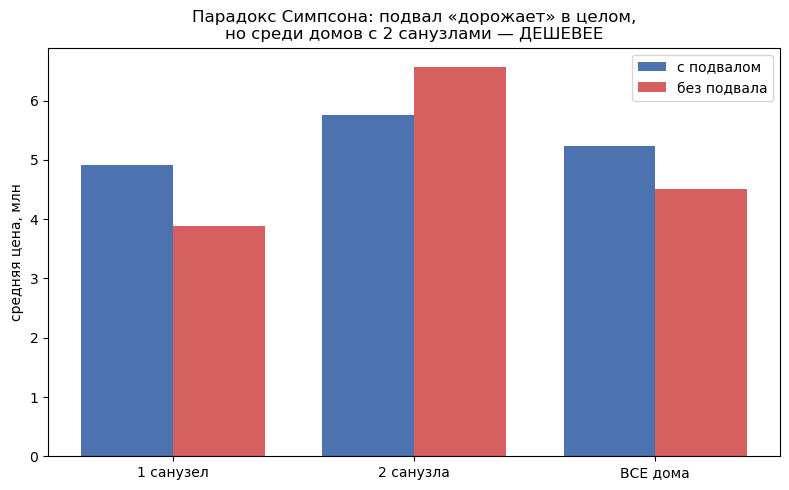

In [14]:
# Крупным планом: basement -> price, разрезанный по числу санузлов (bathrooms)
from scipy import stats

r_all, p_all = stats.pointbiserialr(d["basement"], d["price"])
print("Связь BASEMENT -> PRICE:")
print(f"  на ВСЕХ данных:  r = {r_all:+.3f} (p = {p_all:.1e})  -> с подвалом ДОРОЖЕ\n")

for bt in [1, 2]:
    s = d[d["bathrooms"] == bt]
    r, p = stats.pointbiserialr(s["basement"], s["price"])
    print(f"  среди домов с {bt} санузлами (n={len(s)}): r = {r:+.3f} (p = {p:.3f})")
    print(f"     ср. цена: с подвалом = {s[s.basement==1].price.mean():,.0f}   "
          f"без = {s[s.basement==0].price.mean():,.0f}")

# Визуализация разворота
fig, ax = plt.subplots(figsize=(8, 5))
groups = {"1 санузел": d[d.bathrooms == 1], "2 санузла": d[d.bathrooms == 2],
          "ВСЕ дома": d}
x = np.arange(len(groups)); w = 0.38
withb = [g[g.basement == 1].price.mean() / 1e6 for g in groups.values()]
nob   = [g[g.basement == 0].price.mean() / 1e6 for g in groups.values()]
ax.bar(x - w/2, withb, w, color="#4c72b0", label="с подвалом")
ax.bar(x + w/2, nob,   w, color="#d65f5f", label="без подвала")
ax.set_xticks(x); ax.set_xticklabels(groups.keys())
ax.set_ylabel("средняя цена, млн")
ax.set_title("Парадокс Симпсона: подвал «дорожает» в целом,\nно среди домов с 2 санузлами — ДЕШЕВЕЕ")
ax.legend()
plt.tight_layout()
plt.show()


### Парадокс Симпсона — да, он здесь есть

Скан нашёл развороты знака. Самый чистый и **статистически значимый** — связь подвала с ценой:

| | r(basement ↔ price) | вывод |
|---|---|---|
| на всех 545 домах | **+0.19** (p < 0.001) | с подвалом в среднем **дороже** (5.24 млн против 4.51 млн) |
| среди домов с **1 санузлом** | **+0.34** (p < 0.001) | подвал даёт прибавку к цене |
| среди домов с **2 санузлами** | **−0.21** (p = 0.015) | с подвалом **дешевле** (5.75 млн против 6.56 млн) |

То есть общий вывод «подвал повышает цену» **переворачивается** для домов с двумя санузлами — там подвал связан уже со *снижением* цены, и это значимо (p = 0.015), а не случайный шум.

**Как это понимать.** Bathrooms — индикатор класса дома. В сегменте простых домов (1 санузел) подвал — это плюс к площади и цене. Но среди более дорогих домов (2 санузла) самые премиальные — это новые большие дома **без подвала** (вместо подвала — полноценные надземные этажи), а дома с подвалом в этом сегменте старее и дешевле. Усреднив оба сегмента, мы видим только общий «плюс» и теряем переключение.

**Ещё развороты (слабее / осторожно):**
- `basement → price`, разрез по `stories`: премия за подвал плавно тает с ростом этажности (+0.52 → +0.23 → 0.0 → −0.11) — в многоэтажных домах подвал почти не добавляет ценности.
- `airconditioning → price`, разрез по `hotwaterheating`: формальный разворот, но подгруппа с водяным отоплением всего ~25 домов — это, скорее, шум малой выборки, а не настоящий эффект.

**Практический вывод.** Эффект подвала на цену **зависит от класса дома** — судить о нём по общей корреляции нельзя. Это прямое продолжение находок из раздела про ложные корреляции: одномерная статистика обманчива, нужны либо разрезы по подгруппам, либо множественная регрессия с членами взаимодействия (например `basement × bathrooms`).

## 8. Выбросы в цене и площади

Находим выбросы методом **IQR** (правило 1.5·IQR: значения ниже Q1−1.5·IQR или выше Q3+1.5·IQR) и смотрим, как они влияют на **среднее** и на **корреляцию** price–area.

In [15]:
# Обнаружение выбросов по правилу 1.5*IQR
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

rows = []
masks = {}
for col in ["price", "area"]:
    lo, hi = iqr_bounds(df[col])
    m = (df[col] < lo) | (df[col] > hi)
    masks[col] = m
    rows.append({"признак": col, "нижняя граница": lo, "верхняя граница": hi,
                 "выбросов": int(m.sum()), "доля %": round(m.mean() * 100, 1),
                 "min выброс": df[col][m].min(), "max выброс": df[col][m].max()})

out_mask = masks["price"] | masks["area"]      # строка-выброс хотя бы по одному признаку
print(f"Строк-выбросов (price ИЛИ area): {out_mask.sum()} из {len(df)}\n")
pd.DataFrame(rows)


Строк-выбросов (price ИЛИ area): 25 из 545



,признак,нижняя граница,верхняя граница,выбросов,доля %,min выброс,max выброс
0,price,-35000.0,9205000.0,15,2.8,9240000,13300000
1,area,-540.0,10500.0,12,2.2,10700,16200


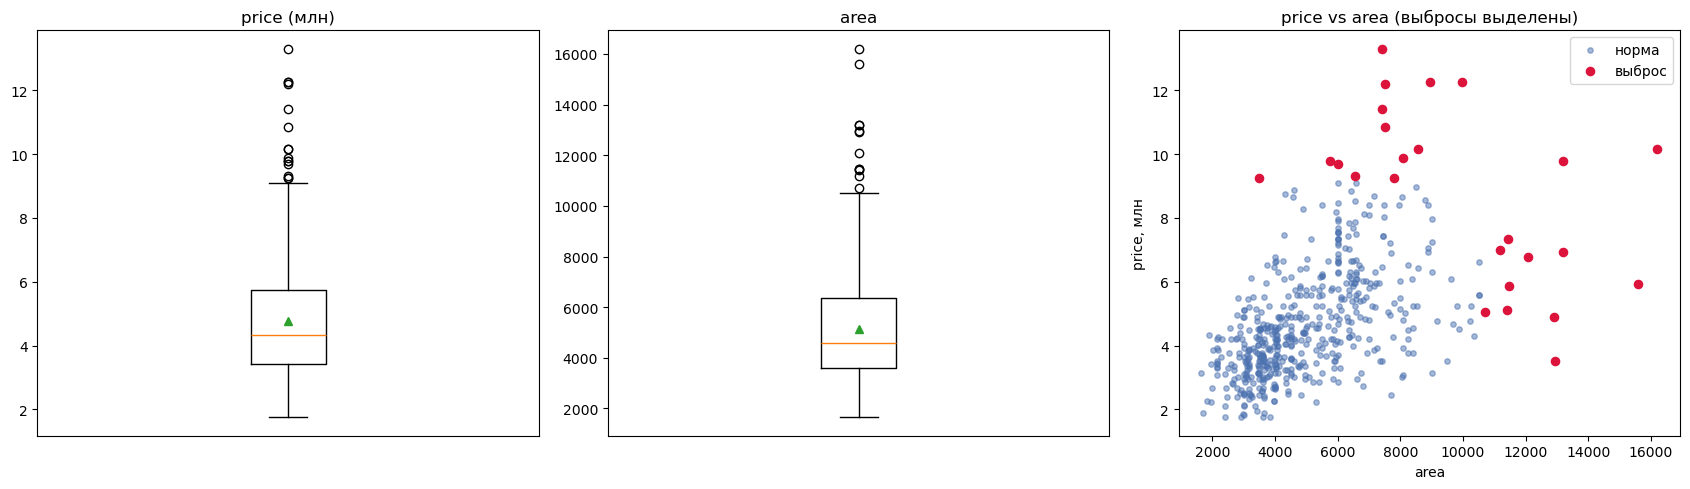

In [16]:
# Визуализация: boxplot'ы и scatter с подсветкой выбросов
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].boxplot(df["price"] / 1e6, showmeans=True)
axes[0].set_title("price (млн)"); axes[0].set_xticks([])
axes[1].boxplot(df["area"], showmeans=True)
axes[1].set_title("area"); axes[1].set_xticks([])

# scatter price vs area: выбросы красным
ax = axes[2]
ax.scatter(df["area"][~out_mask], df["price"][~out_mask] / 1e6,
           s=15, alpha=.5, color="#4c72b0", label="норма")
ax.scatter(df["area"][out_mask], df["price"][out_mask] / 1e6,
           s=35, color="crimson", label="выброс")
ax.set_xlabel("area"); ax.set_ylabel("price, млн")
ax.set_title("price vs area (выбросы выделены)")
ax.legend()

plt.tight_layout()
plt.show()


In [17]:
# Влияние выбросов на среднее и корреляцию: сравнение "с" и "без"
clean = df[~out_mask]

stats_cmp = pd.DataFrame({
    "с выбросами": {
        "mean price":   df["price"].mean(),
        "median price": df["price"].median(),
        "mean area":    df["area"].mean(),
        "median area":  df["area"].median(),
        "corr price-area (Pearson)":  df["price"].corr(df["area"]),
        "corr price-area (Spearman)": df["price"].corr(df["area"], method="spearman"),
    },
    "без выбросов": {
        "mean price":   clean["price"].mean(),
        "median price": clean["price"].median(),
        "mean area":    clean["area"].mean(),
        "median area":  clean["area"].median(),
        "corr price-area (Pearson)":  clean["price"].corr(clean["area"]),
        "corr price-area (Spearman)": clean["price"].corr(clean["area"], method="spearman"),
    },
})
stats_cmp["изменение %"] = (stats_cmp["без выбросов"] / stats_cmp["с выбросами"] - 1) * 100
stats_cmp.round(3)


,с выбросами,без выбросов,изменение %
mean price,4766729.248,4576773.923,-3.985
median price,4340000.000,4270000.000,-1.613
mean area,5150.541,4922.473,-4.428
median area,4600.000,4500.000,-2.174
corr price-area (Pearson),0.536,0.532,-0.663
corr price-area (Spearman),0.603,0.581,-3.577


### Выбросы и их влияние — выводы

**Сколько и какие.** По правилу 1.5·IQR:
- **price:** 15 выбросов (2.8 %) — все «сверху», дорогие дома 9.24–13.3 млн (граница 9.2 млн);
- **area:** 12 выбросов (2.2 %) — все «сверху», большие участки 10 700–16 200 (граница 10 500);
- всего 25 строк-выбросов хотя бы по одному признаку. Все выбросы односторонние (только большие значения) — распределения скошены вправо, что типично для цен на недвижимость.

**Влияние на среднее.** Выбросы заметно **завышают среднее**, но почти не трогают медиану:
- mean price: 4.77 млн → 4.58 млн без выбросов (**−4.0 %**); median price сдвигается лишь на −1.6 %;
- mean area: 5151 → 4922 (**−4.4 %**).

То есть несколько дорогих/больших домов тянут среднее вверх — поэтому для скошенных признаков **медиана честнее** описывает «типичный» дом, чем среднее. (Это перекликается с тем, что mean > median в описательной статистике.)

**Влияние на корреляцию.** А вот корреляцию price–area выбросы **почти не меняют**:
- Pearson: 0.536 → 0.532 (изменение < 1 %);
- Spearman: 0.603 → 0.581.

Связь не держится на выбросах — она есть и в основной массе домов. Более того, Spearman (0.60) **выше** Pearson (0.54): зависимость монотонная и слегка нелинейная, а дорогие особняки лишь чуть-чуть «прижимают» линейный Pearson вниз, не создавая ложной корреляции.

**Практический вывод.**
- Эти выбросы — не ошибки, а реальные дорогие/крупные дома (премиум-сегмент), удалять их без причины не стоит.
- Для отчёта о «типичной» цене лучше приводить **медиану**, а не среднее (среднее завышено на ~4 %).
- Корреляция price–area **устойчива** к выбросам, ей можно доверять; но раз Spearman > Pearson, для моделирования цены имеет смысл рассмотреть нелинейность (например логарифм цены/площади).

## 9. Нелинейные зависимости цены от ключевых признаков

Проверяем, линейна ли связь цены с признаками, тремя способами:
1. **Pearson vs Spearman** — если Spearman заметно больше, связь монотонная, но не линейная;
2. **R² линейной vs квадратичной vs лог-модели** — насколько кривая описывает данные лучше прямой;
3. **средняя цена по группам** — визуально видно изгиб (насыщение / ускорение).

In [18]:
# Линейность vs нелинейность: Pearson/Spearman и R2 разных моделей
y = df["price"].values
key_feats = ["area", "bathrooms", "bedrooms", "stories", "parking"]

def r2(pred):
    return np.corrcoef(pred, y)[0, 1] ** 2

rows = []
for f in key_feats:
    x = df[f].values.astype(float)
    pe = df[f].corr(df["price"])
    sp = df[f].corr(df["price"], method="spearman")
    r2_lin  = r2(np.polyval(np.polyfit(x, y, 1), x))
    r2_quad = r2(np.polyval(np.polyfit(x, y, 2), x))
    r2_logx = r2(np.polyval(np.polyfit(np.log(x), y, 1), np.log(x)))
    rows.append({"feature": f, "pearson": pe, "spearman": sp,
                 "gap (sp-pe)": sp - pe,
                 "R2 линейн.": r2_lin, "R2 квадрат.": r2_quad, "R2 log(x)": r2_logx,
                 "прирост R2 (квад-лин)": r2_quad - r2_lin})

nonlin = pd.DataFrame(rows)
nonlin.round(3)


C:\Users\Админ\AppData\Local\Temp\ipykernel_2708\2118048024.py:15: RuntimeWarning: divide by zero encountered in log
  r2_logx = r2(np.polyval(np.polyfit(np.log(x), y, 1), np.log(x)))
C:\Anaconda2026\Lib\site-packages\numpy\lib\_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

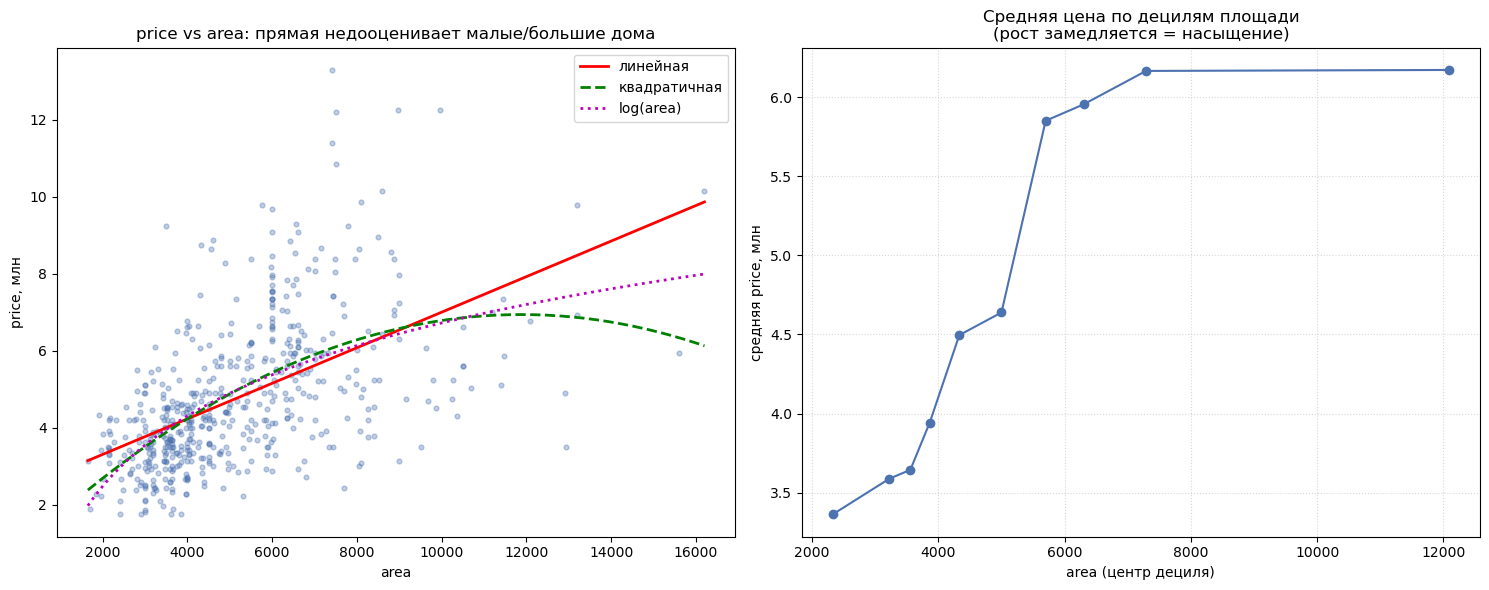

In [19]:
# area vs price: облако точек + линейная и квадратичная подгонки + средняя по децилям
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = df["area"].values.astype(float)
xs = np.linspace(x.min(), x.max(), 200)
ax = axes[0]
ax.scatter(x, y / 1e6, s=12, alpha=.35, color="#4c72b0")
ax.plot(xs, np.polyval(np.polyfit(x, y, 1), xs) / 1e6, "r-",  lw=2, label="линейная")
ax.plot(xs, np.polyval(np.polyfit(x, y, 2), xs) / 1e6, "g--", lw=2, label="квадратичная")
ax.plot(xs, np.polyval(np.polyfit(np.log(x), y, 1), np.log(xs)) / 1e6, "m:", lw=2, label="log(area)")
ax.set_xlabel("area"); ax.set_ylabel("price, млн")
ax.set_title("price vs area: прямая недооценивает малые/большие дома")
ax.legend()

# средняя цена по децилям площади — видно насыщение
ax = axes[1]
bins = pd.qcut(df["area"], 10)
means = df.groupby(bins, observed=True)["price"].mean() / 1e6
centers = [iv.mid for iv in means.index]
ax.plot(centers, means.values, "o-", color="#4c72b0")
ax.set_xlabel("area (центр дециля)"); ax.set_ylabel("средняя price, млн")
ax.set_title("Средняя цена по децилям площади\n(рост замедляется = насыщение)")
ax.grid(ls=":", alpha=.5)

plt.tight_layout()
plt.show()


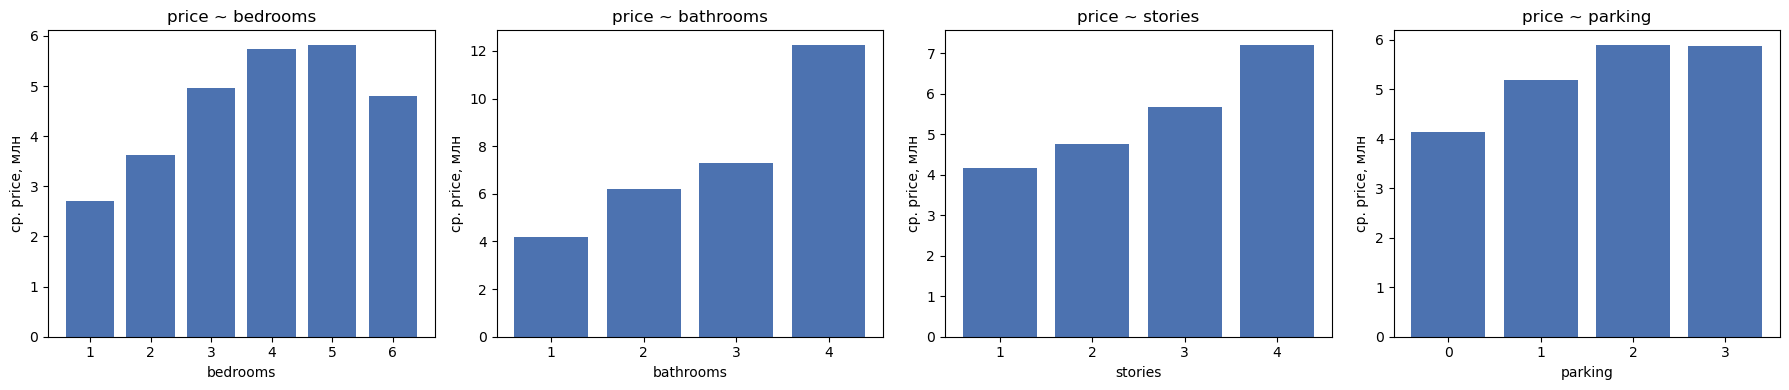

In [20]:
# Дискретные признаки: средняя цена по каждому значению (видно форму зависимости)
disc = ["bedrooms", "bathrooms", "stories", "parking"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, f in zip(axes, disc):
    g = df.groupby(f)["price"].mean() / 1e6
    ax.bar(g.index.astype(str), g.values, color="#4c72b0")
    ax.set_title(f"price ~ {f}")
    ax.set_xlabel(f); ax.set_ylabel("ср. price, млн")

plt.tight_layout()
plt.show()


### Нелинейные зависимости — выводы

Нелинейность есть, и у разных признаков она разной формы:

**`area` — насыщение (вогнутая связь), самый яркий случай.**
- Spearman (0.60) > Pearson (0.54) → связь монотонная, но не прямая.
- R² растёт от линейной модели к нелинейным: 0.287 → 0.323 (квадрат) → лог-лог `log(price)~log(area)` **0.336**. Логарифмическая шкала описывает цену заметно лучше прямой.
- На графике средних по децилям цена быстро растёт у малых домов и **выходит на плато** после ~6000 (деции 6.6k и 16k дают почти одинаковые ~6.2 млн). Это «убывающая отдача»: первые метры площади дороги, лишние сотки сверх большого дома почти не добавляют цены.

**`bedrooms` — немонотонная связь.** Средняя цена растёт с 1 до 5 спален (2.71 → 5.82 млн), но при **6 спальнях падает** до 4.79 млн. Связь не просто нелинейна — она разворачивается. Отчасти поэтому корреляция `bedrooms–price` слабая и (как мы видели) во многом ложная: больше спален при той же площади = теснее комнаты, не дороже.

**`parking` — насыщение.** Цена растёт от 0 до 2 мест (4.14 → 5.90 млн) и **перестаёт расти** на 3 местах (5.87). Третье парковочное место ценность уже не добавляет.

**`bathrooms` — ускорение (выпуклая).** Цена растёт всё быстрее: 4.21 → 6.21 → 7.28 → 12.25 млн. Но в группах 3–4 санузла мало домов (11 шт), так что «ускорение» на конце — на малой выборке; в основной массе связь близка к линейной (R² квадрата = R² линейной).

**`stories` — практически линейная** (4.17 → 4.76 → 5.69 → 7.21 млн), нелинейные модели почти не улучшают R².

**Практический вывод.** Линейная корреляция/регрессия по «сырым» признакам недооценивает связь, особенно для площади. Для модели цены стоит:
- брать **`log(area)`** (а лучше `log(price) ~ log(area)`) — это и снимет вогнутость, и стабилизирует разброс;
- учитывать **немонотонность** `bedrooms` и **насыщение** `parking` (например через категориальное кодирование, а не как число);
- помнить, что один коэффициент корреляции скрывает форму связи — её видно только на графиках средних по группам.

## Выводы

**Датасет:** 545 объявлений, 13 признаков, пропусков нет. 6 числовых + 6 бинарных (yes/no) + 1 порядковый (`furnishingstatus`).

**Что определяет цену (корреляция с `price`, все значимы при p < 0.05):**

| признак | r | смысл |
|---|---|---|
| area | **0.54** | площадь — главный фактор цены |
| bathrooms | **0.52** | число санузлов |
| airconditioning | 0.45 | наличие кондиционера |
| stories | 0.42 | этажность |
| parking | 0.38 | число парковочных мест |
| bedrooms | 0.37 | число спален |
| prefarea | 0.33 | престижный район |
| furnishingstatus | 0.31 | меблировка |
| mainroad | 0.30 | выход на главную дорогу |
| guestroom, basement | 0.26 / 0.19 | гостевая, подвал |
| hotwaterheating | 0.09 | почти не влияет |

**Главные выводы:**
- Цена сильнее всего связана с **площадью** и **числом санузлов** (r ≈ 0.52–0.54), но связь умеренная: даже площадь объясняет лишь ~29 % разброса цены (r² = 0.29). Цена определяется совокупностью факторов, одного признака мало.
- Все связи с ценой **положительные** и статистически значимы; самый слабый предиктор — `hotwaterheating` (r = 0.09).
- Среди признаков между собой заметны логичные связи: `bedrooms–stories` (0.41), `bedrooms–bathrooms` (0.37), `guestroom–basement` (0.37) — больше дом, больше всего.
- Из 78 пар признаков значимы 54 (p < 0.05), но большинство связей **слабые** (|r| < 0.4): мультиколлинеарность не критична, признаки несут в основном независимую информацию.

**Оговорки:** Pearson на бинарных/порядковых признаках = точечно-бисериальная / ранговая корреляция, её можно интерпретировать, но осторожно; корреляция не доказывает причинность; для предсказания цены логичный следующий шаг — регрессия с этими признаками.